In [2]:
import h5py
f = h5py.File('../../project/lofarsw/Data/Dynspec/labelled_dataset.h5', 'r')
list(f.keys())

['data', 'freq_range', 'indices', 'labels', 'time_range', 'timestamps']

Since the number of samples for type 2 is really small right now, we will train again to see model perfomance for 3 clasess - type 1, type 3, type 6. Keeping the model architechire exactly same. We also have filtered images so lets use that now instead of unfiltered images. 

In [1]:
# %% [markdown]
# YOLO-style classifier (3 classes: 1, 3, 6) — filtered images version

# %%
import os, math, random, h5py
import numpy as np
import pandas as pd
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
# %%
# ---- Paths ----
H5_PATH = "../../project/lofarsw/Data/Dynspec/labelled_datasetlabeled_bgmed_filtered.h5"  # adjust if needed
SAVE_PATH = "yolo_cls_1_3_6.pth"

# ---- Class selection ----
SELECTED_LABELS = [1, 3, 6]  # 1-indexed in your dataset
CLASS_TO_INDEX = {1: 0, 3: 1, 6: 2}  # mapping to [0,1,2]
CLASS_NAMES = ["Type 1", "Type 3", "Nothing (6)"]

# How to handle samples with multiple labels touching our subset:
# "strict": keep only samples that have exactly one of {1,3,6} and NO other class
# "priority": if multiple present, pick the highest-priority (define below)
FILTER_MODE = "strict"
PRIORITY_ORDER = [1, 3, 6]  # used only if FILTER_MODE="priority"

# Training hyperparams
IMG_SIZE = (224, 224)          # resize target (H,W)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 7.14e-4
WEIGHT_DECAY = 1e-4            # L2 reg
BETA1, BETA2 = 0.9, 0.999      # AdamW momentum terms
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15


In [12]:
# %%
def to_multi_hot(raw_label, num_classes=6):
    """raw_label can be scalar or array-like (1-indexed). Return 6-length multi-hot (float32)."""
    v = np.zeros(num_classes, dtype=np.float32)
    if np.isscalar(raw_label):
        idxs = [int(raw_label)]
    else:
        idxs = list(np.array(raw_label).reshape(-1))
    for lab in idxs:
        if 1 <= int(lab) <= num_classes:
            v[int(lab) - 1] = 1.0
    # Enforce 'Nothing' exclusivity at preprocessing time:
    # if any of classes {1..5} present, force class 6 to 0.
    if v[:5].sum() > 0:
        v[5] = 0.0
    return v

def pick_single_label_from_subset(mh: np.ndarray) -> int:
    """
    Given a 6-dim multi-hot vector (0/1), decide a single label in {2,3,6} or return -1 to drop.
    - strict: keep only if exactly one of {2,3,6} is 1 and no other class is 1.
    - priority: if multiple among {2,3,6} are 1, choose by PRIORITY_ORDER; drop if any other class is on.
    """
    # any other class on?
    other_on = mh[[i for i in range(6) if (i+1) not in SELECTED_LABELS]].sum() > 0

    sel_mask = np.array([mh[lab-1] for lab in SELECTED_LABELS], dtype=np.float32)
    sel_count = int(sel_mask.sum())

    if FILTER_MODE == "strict":
        if other_on: 
            return -1
        if sel_count == 1:
            chosen_lab = SELECTED_LABELS[int(np.argmax(sel_mask))]
            return CLASS_TO_INDEX[chosen_lab]
        return -1  # drop multi or zero
    else:  # "priority"
        if other_on:
            return -1
        if sel_count == 0:
            return -1
        # pick by priority order
        for lab in PRIORITY_ORDER:
            if mh[lab-1] == 1.0:
                return CLASS_TO_INDEX[lab]
        return -1




In [13]:
# %%
with h5py.File(H5_PATH, "r") as f:
    data = f["data"][:]          # Expect (N, H, W) or (N, H, W, 1)
    labels_raw = f["labels"][:]  # Could be (N,) or (N,k)
    timestamps = f["timestamps"][:]

# Decode timestamps if bytes
timestamps = np.array([
    t.decode("utf-8") if isinstance(t, (bytes, bytearray)) else str(t) 
    for t in timestamps
])

# Ensure (N,H,W,1)
if data.ndim == 3:
    data = data[..., None]
elif data.ndim == 4 and data.shape[-1] != 1:
    data = data.mean(axis=-1, keepdims=True).astype(np.float32)

# Build multi-hot and then filter to single label in {2,3,6}
multi_hot = np.zeros((len(labels_raw), 6), dtype=np.float32)
for i in range(len(labels_raw)):
    multi_hot[i] = to_multi_hot(labels_raw[i])

# --- 0) Make arrays the same length & drop non-finite frames first ---
N = min(len(data), len(labels_raw), len(timestamps))
data = data[:N]
labels_raw = labels_raw[:N]
timestamps = timestamps[:N]

finite_mask = np.isfinite(data).all(axis=(1,2,3))
if finite_mask.sum() != N:
    data = data[finite_mask]
    labels_raw = labels_raw[finite_mask]
    timestamps = timestamps[finite_mask]

print("After alignment:", len(data), len(labels_raw), len(timestamps))

# --- 1) Build multi-hot from the ALIGNED labels ---
multi_hot = np.zeros((len(labels_raw), 6), dtype=np.float32)
for i in range(len(labels_raw)):
    multi_hot[i] = to_multi_hot(labels_raw[i])

# --- 2) Pick single label ONLY from {2,3,6} using a boolean keep-mask ---
keep_mask = np.zeros(len(data), dtype=bool)
y_single = np.full(len(data), -1, dtype=np.int64)

for i in range(len(data)):
    cls = pick_single_label_from_subset(multi_hot[i])
    if cls != -1:
        keep_mask[i] = True
        y_single[i] = cls

# --- 3) Apply the mask (no index list -> no out-of-bounds) ---
X = data[keep_mask]
y = y_single[keep_mask]
ts_kept = np.array(timestamps)[keep_mask]

print("Kept samples:", len(X))
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", {k: int(v) for k, v in zip(unique, counts)})

print("Kept samples:", len(X))
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip([CLASS_NAMES[u] for u in unique], counts)))


After alignment: 4878 4878 4878
Kept samples: 3976
Class distribution: {0: 443, 1: 2757, 2: 776}
Kept samples: 3976
Class distribution: {'Type 1': 443, 'Type 3': 2757, 'Nothing (6)': 776}


In [14]:
# %%
# First split off test; then split train into train/val
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=SEED)
train_val_idx, test_idx = next(sss1.split(np.zeros(len(y)), y))

X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]
X_test, y_test = X[test_idx], y[test_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT/(1.0-TEST_SPLIT), random_state=SEED)
train_idx, val_idx = next(sss2.split(np.zeros(len(y_train_val)), y_train_val))

X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
X_val,   y_val   = X_train_val[val_idx],   y_train_val[val_idx]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 2782 | Val: 597 | Test: 597


In [15]:
class DynspecClsDataset(Dataset):
    def __init__(self, imgs, labels, target_size=(224,224)):
        self.imgs = imgs.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.target_size = target_size

    def __len__(self): 
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx]  # (H,W,1)
        # Replace non-finite with 0 BEFORE min/max
        img = np.where(np.isfinite(img), img, 0.0)

        # safe per-sample normalisation to [0,1]
        mn = np.nanmin(img)
        mx = np.nanmax(img)
        denom = mx - mn
        if not np.isfinite(denom) or denom <= 0:
            # fallback if flat or weird
            img = np.clip(img, 0.0, 1.0)
        else:
            img = (img - mn) / denom
            img = np.clip(img, 0.0, 1.0)

        # CHW tensor
        img = torch.from_numpy(img.transpose(2,0,1))

        # resize (bilinear)
        if img.shape[-2:] != self.target_size:
            img = torch.nn.functional.interpolate(
                img.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False
            ).squeeze(0)

        # Final guard (no NaNs to the net)
        img = torch.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0).contiguous()

        label = int(self.labels[idx])  # 0..2
        return img, label

train_ds = DynspecClsDataset(X_train, y_train, IMG_SIZE)
val_ds   = DynspecClsDataset(X_val,   y_val,   IMG_SIZE)
test_ds  = DynspecClsDataset(X_test,  y_test,  IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=1, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)

print("Any non-finite in X?", ~np.isfinite(X).all())
print("Label set:", np.unique(y))
print("Train/Val/Test sizes:", len(X_train), len(X_val), len(X_test))



Any non-finite in X? False
Label set: [0 1 2]
Train/Val/Test sizes: 2782 597 597


In [7]:
# %%
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, s=1, p=0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, stride=s, padding=p, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.SiLU()
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class C2F(nn.Module):
    def __init__(self, ch, expansion=0.5, n=1):
        super().__init__()
        hid = int(ch*expansion)
        self.cv1 = ConvBlock(ch, hid, 1)
        self.cv2 = ConvBlock(ch, hid, 1)
        self.blocks = nn.Sequential(*[ConvBlock(hid, hid, 3, p=1) for _ in range(n)])
        self.cv3 = ConvBlock(hid*2, ch, 1)
    def forward(self, x):
        y1 = self.cv1(x)
        y2 = self.cv2(x)
        return self.cv3(torch.cat([y1, self.blocks(y2)], dim=1))

class SPPF(nn.Module):
    def __init__(self, in_ch, out_ch, k=5):
        super().__init__()
        hid = in_ch // 2
        self.cv1 = ConvBlock(in_ch, hid, 1)
        self.pool = nn.MaxPool2d(k, stride=1, padding=k//2)
        self.cv2 = ConvBlock(hid*4, out_ch, 1)
    def forward(self, x):
        x = self.cv1(x)
        y1 = self.pool(x)
        y2 = self.pool(y1)
        y3 = self.pool(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], dim=1))

class YOLOClassifier(nn.Module):
    def __init__(self, num_classes=3, input_hw=(224,224)):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(1,   32, 3, s=1, p=1),
            ConvBlock(32,  64, 3, s=2, p=1),
            C2F(64,  0.5, n=1),
            ConvBlock(64, 128, 3, s=2, p=1),
            C2F(128, 0.5, n=3),
            ConvBlock(128, 256, 3, s=2, p=1),
            C2F(256, 0.5, n=3),
            ConvBlock(256, 512, 3, s=2, p=1),
            C2F(512, 0.5, n=1),
        )
        self.neck = SPPF(512, 512, k=5)

        # infer flatten dim dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_hw[0], input_hw[1])
            feat = self.neck(self.backbone(dummy))
            flat_dim = feat.numel()

        self.flatten = nn.Flatten()
        self.fc1  = nn.Linear(flat_dim, 128)
        self.drop1 = nn.Dropout(0.5)
        self.fc2  = nn.Linear(128, 128)
        self.drop2 = nn.Dropout(0.5)
        self.fc3  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.neck(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        logits = self.fc3(x)
        return logits  # softmax to be applied by loss or eval


In [8]:
# %%
# Hyperparams tweak
LEARNING_RATE = 5e-4  # was 7.14e-4; a bit safer
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=1, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)

def train_one_epoch(model, loader, criterion, optimizer, max_grad_norm=5.0):
    model.train(); total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        # guard: no NaNs go in
        if not torch.isfinite(imgs).all():
            imgs = torch.nan_to_num(imgs, nan=0.0, posinf=1.0, neginf=0.0)

        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)

        # guard: no NaNs come out
        if not torch.isfinite(logits).all():
            logits = torch.nan_to_num(logits, nan=0.0, posinf=1e3, neginf=-1e3)

        loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            # skip the batch if still bad
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    return (loss_sum / max(total,1)), (correct / max(total,1))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        if not torch.isfinite(imgs).all():
            imgs = torch.nan_to_num(imgs, nan=0.0, posinf=1.0, neginf=0.0)
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss_sum += float(loss) * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return (loss_sum / max(total,1)), (correct / max(total,1))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss_sum += loss.item() * imgs.size(0)
        pred = logits.argmax(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return loss_sum/total, correct/total

model = YOLOClassifier(num_classes=3, input_hw=IMG_SIZE).to(device)
criterion = nn.CrossEntropyLoss()  # softmax+CE for multi-class
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              betas=(BETA1, BETA2), weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5, min_lr=1e-6)

best_val_acc, best_state = 0.0, None
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step(va_loss)
    print(f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} | val_loss {va_loss:.4f} acc {va_acc:.4f}")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), SAVE_PATH)
    print(f"Saved best model: {SAVE_PATH} (val_acc={best_val_acc:.4f})")


/home/lofarsw-aaditya/test_venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | train_loss 1.1850 acc 0.6988 | val_loss 0.7641 acc 0.8208
Epoch 02 | train_loss 0.8267 acc 0.7937 | val_loss 1.4434 acc 0.8358
Epoch 03 | train_loss 0.7516 acc 0.8027 | val_loss 1.5348 acc 0.8308
Epoch 04 | train_loss 0.6367 acc 0.8138 | val_loss 0.4845 acc 0.8258
Epoch 05 | train_loss 0.5770 acc 0.8242 | val_loss 0.4489 acc 0.8342
Epoch 06 | train_loss 0.5254 acc 0.8329 | val_loss 0.6220 acc 0.8325
Epoch 07 | train_loss 0.6056 acc 0.8347 | val_loss 0.6407 acc 0.8375
Epoch 08 | train_loss 0.4803 acc 0.8400 | val_loss 0.4782 acc 0.8325
Epoch 09 | train_loss 0.4627 acc 0.8375 | val_loss 0.4165 acc 0.8509
Epoch 10 | train_loss 0.4245 acc 0.8630 | val_loss 0.4135 acc 0.8576
Epoch 11 | train_loss 0.3872 acc 0.8638 | val_loss 0.3762 acc 0.8593
Epoch 12 | train_loss 0.3576 acc 0.8645 | val_loss 0.3692 acc 0.8744
Epoch 13 | train_loss 0.3741 acc 0.8706 | val_loss 0.4328 acc 0.8559
Epoch 14 | train_loss 0.3266 acc 0.8843 | val_loss 0.3456 acc 0.8894
Epoch 15 | train_loss 0.3559 acc 0

/home/lofarsw-aaditya/test_venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Classification report (TEST):
              precision    recall  f1-score   support

      Type 1     0.7742    0.3636    0.4948        66
      Type 3     0.9188    0.9565    0.9373       414
 Nothing (6)     0.8370    0.9658    0.8968       117

    accuracy                         0.8928       597
   macro avg     0.8433    0.7620    0.7763       597
weighted avg     0.8868    0.8928    0.8804       597



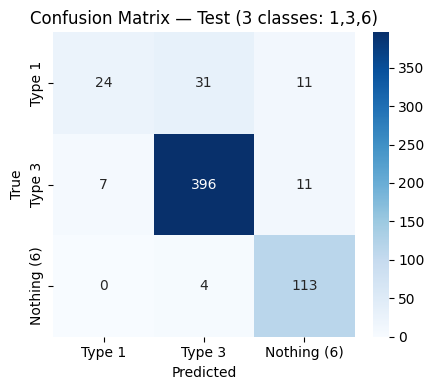

In [10]:
# %%
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    probs, labels_all = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        p = F.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)
        labels_all.append(labels.numpy())
    return np.vstack(probs), np.concatenate(labels_all)

test_probs, test_labels = predict_all(model, test_loader)
test_pred = test_probs.argmax(axis=1)

print("\nClassification report (TEST):")
print(classification_report(test_labels, test_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(test_labels, test_pred)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Test (3 classes: 1,3,6)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


### Compare type 1,3,6 filtered (above) and unfiltered images (below) model. Using everything same just changing the input data. 

This justifyes the need for filtering. 

In [11]:
# ---- Paths ----
H5_PATH = "../../project/lofarsw/Data/Dynspec/labelled_dataset.h5"  # adjust if needed
SAVE_PATH = "yolo_cls_1_3_6_unfiltered.pth"

In [16]:
# %%
# Hyperparams tweak
LEARNING_RATE = 5e-4  # was 7.14e-4; a bit safer
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=1, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)

def train_one_epoch(model, loader, criterion, optimizer, max_grad_norm=5.0):
    model.train(); total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        # guard: no NaNs go in
        if not torch.isfinite(imgs).all():
            imgs = torch.nan_to_num(imgs, nan=0.0, posinf=1.0, neginf=0.0)

        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)

        # guard: no NaNs come out
        if not torch.isfinite(logits).all():
            logits = torch.nan_to_num(logits, nan=0.0, posinf=1e3, neginf=-1e3)

        loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            # skip the batch if still bad
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    return (loss_sum / max(total,1)), (correct / max(total,1))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        if not torch.isfinite(imgs).all():
            imgs = torch.nan_to_num(imgs, nan=0.0, posinf=1.0, neginf=0.0)
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss_sum += float(loss) * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return (loss_sum / max(total,1)), (correct / max(total,1))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total, correct, loss_sum = 0, 0, 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss_sum += loss.item() * imgs.size(0)
        pred = logits.argmax(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return loss_sum/total, correct/total

model = YOLOClassifier(num_classes=3, input_hw=IMG_SIZE).to(device)
criterion = nn.CrossEntropyLoss()  # softmax+CE for multi-class
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              betas=(BETA1, BETA2), weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5, min_lr=1e-6)

best_val_acc, best_state = 0.0, None
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step(va_loss)
    print(f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} | val_loss {va_loss:.4f} acc {va_acc:.4f}")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), SAVE_PATH)
    print(f"Saved best model: {SAVE_PATH} (val_acc={best_val_acc:.4f})")


/home/lofarsw-aaditya/test_venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | train_loss 1.1108 acc 0.6096 | val_loss 0.8072 acc 0.6951
Epoch 02 | train_loss 0.8953 acc 0.6697 | val_loss 1.0112 acc 0.6951
Epoch 03 | train_loss 0.9971 acc 0.6592 | val_loss 0.8070 acc 0.6884
Epoch 04 | train_loss 0.8500 acc 0.6887 | val_loss 0.6897 acc 0.7052
Epoch 05 | train_loss 0.7577 acc 0.7006 | val_loss 0.7261 acc 0.7085
Epoch 06 | train_loss 0.6878 acc 0.6991 | val_loss 0.6261 acc 0.7002
Epoch 07 | train_loss 0.6775 acc 0.6984 | val_loss 0.6779 acc 0.7052
Epoch 08 | train_loss 0.6652 acc 0.7013 | val_loss 0.5836 acc 0.7270
Epoch 09 | train_loss 0.6266 acc 0.7168 | val_loss 0.6470 acc 0.7085
Epoch 10 | train_loss 0.6053 acc 0.7473 | val_loss 0.5629 acc 0.7253
Epoch 11 | train_loss 0.5541 acc 0.7800 | val_loss 0.5417 acc 0.8224
Epoch 12 | train_loss 0.5276 acc 0.8048 | val_loss 0.4504 acc 0.8291
Epoch 13 | train_loss 0.4904 acc 0.8257 | val_loss 0.4263 acc 0.8476
Epoch 14 | train_loss 0.4657 acc 0.8214 | val_loss 0.4124 acc 0.8559
Epoch 15 | train_loss 0.4627 acc 0

KeyboardInterrupt: 


Classification report (TEST):
              precision    recall  f1-score   support

      Type 1     0.7778    0.4242    0.5490        66
      Type 3     0.9097    0.9493    0.9291       414
 Nothing (6)     0.8062    0.8889    0.8455       117

    accuracy                         0.8794       597
   macro avg     0.8312    0.7541    0.7745       597
weighted avg     0.8748    0.8794    0.8707       597



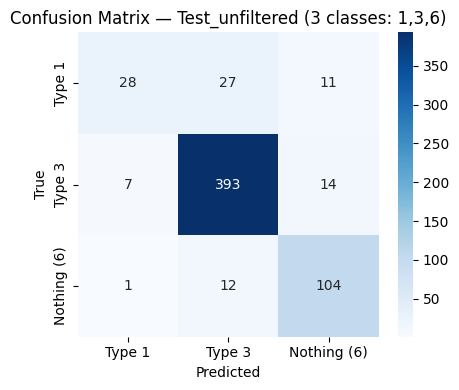

In [17]:
# %%
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    probs, labels_all = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        p = F.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)
        labels_all.append(labels.numpy())
    return np.vstack(probs), np.concatenate(labels_all)

test_probs, test_labels = predict_all(model, test_loader)
test_pred = test_probs.argmax(axis=1)

print("\nClassification report (TEST):")
print(classification_report(test_labels, test_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(test_labels, test_pred)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Test_unfiltered (3 classes: 1,3,6)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()
